In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# ml libraries 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier,GradientBoostingClassifier

# Import Logging Libraries
import logging
logging.basicConfig(level = logging.INFO,
                    filename = 'model.log',
                    filemode = 'w',
                    format = '%(asctime)s -%(message)s - %(levelname)s',
                    force = True)
# Import Filter Warning Libraries
import warnings
warnings.filterwarnings(action = 'ignore')


In [2]:
df=pd.read_csv(r'E:\telecom_churnmodel_prediction\data\churn.csv')
df.sample(frac=1)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
1456,3473-XIIIT,Female,0,Yes,No,16,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.00,1534.75,Yes
6737,9488-FYQAU,Female,0,Yes,No,63,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),109.25,6841.4,No
428,4360-PNRQB,Male,0,No,No,18,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),75.60,1395.05,No
4610,2889-FPWRM,Male,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Bank transfer (automatic),117.80,8684.8,Yes
712,9661-JALZV,Female,0,No,No,58,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),24.70,1519,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4451,1608-GMEWB,Male,1,No,No,45,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),93.90,4200.25,No
3345,1335-HQMKX,Female,0,Yes,No,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Electronic check,101.35,7323.15,No
1437,1666-JZPZT,Male,0,No,No,27,Yes,Yes,DSL,No,...,No,No,No,No,Month-to-month,No,Mailed check,49.00,1291.35,No
2515,8869-LIHMK,Female,0,No,No,64,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),115.10,7334.05,No


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
print("duplicated:",df.duplicated().sum())

duplicated: 0


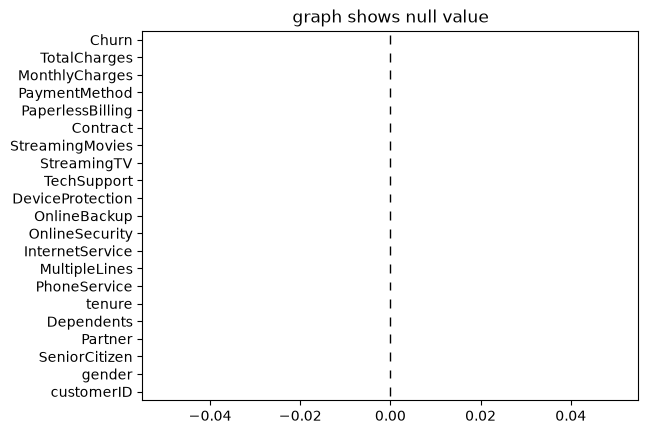

In [5]:
df.isnull().sum().plot(kind='barh',color="grey",edgecolor="k")
plt.title("graph shows null value")
plt.show()

In [6]:
df['Churn']=df['Churn'].map({'Yes':1,'No':0})


In [7]:
df['Churn']

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64

In [8]:
from collections import OrderedDict
stats=[]
for i in df.select_dtypes(exclude=object):
    numericalstats=OrderedDict({
        'feacture':i,
        'count':df[i].count(),
        'mean':df[i].mean(),
        'median':df[i].median(),
        'max':df[i].max(),
        'min':df[i].min(),
        'Q1':df[i].quantile(0.25),
        'Q3':df[i].quantile(0.75),
        'IQR':df[i].quantile(0.75)-df[i].quantile(0.25),
        'LW':(df[i].quantile(0.25)-1.5*(df[i].quantile(0.75)-df[i].quantile(0.25))),
        'UP':(df[i].quantile(0.75)+1.5*(df[i].quantile(0.75)-df[i].quantile(0.25))),
        'skew':df[i].skew(),
        'kurt':df[i].kurt()


    }) 
    stats.append(numericalstats)
    report=pd.DataFrame(stats)
report

,feacture,count,mean,median,max,min,Q1,Q3,IQR,LW,UP,skew,kurt
0,SeniorCitizen,7043,0.162147,0.00,1.00,0.00,0.0,0.00,0.00,0.000,0.000,1.833633,1.362596
1,tenure,7043,32.371149,29.00,72.00,0.00,9.0,55.00,46.00,-60.000,124.000,0.239540,-1.387372
2,MonthlyCharges,7043,64.761692,70.35,118.75,18.25,35.5,89.85,54.35,-46.025,171.375,-0.220524,-1.257260
3,Churn,7043,0.265370,0.00,1.00,0.00,0.0,1.00,1.00,-1.500,2.500,1.063031,-0.870211


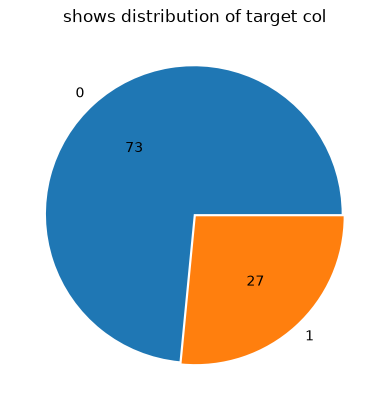

In [7]:
df['Churn'].value_counts().plot(kind='pie',autopct='%0.0f',explode=[0.01,0.01])
plt.title('shows distribution of target col')
plt.show()

In [10]:
df.describe(include=object)

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11


In [6]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

for i in df.select_dtypes(include='object'):
    df[i]=le.fit_transform(df[i])
df



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5375,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,2505,0
1,3962,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1466,0
2,2564,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,157,1
3,5535,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1400,0
4,6511,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,925,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,4853,1,0,1,1,24,1,2,0,2,...,2,2,2,2,1,1,3,84.80,1597,0
7039,1525,0,0,1,1,72,1,2,1,0,...,2,0,2,2,1,1,1,103.20,5698,0
7040,3367,0,0,1,1,11,0,1,0,2,...,0,0,0,0,0,1,2,29.60,2994,0
7041,5934,1,1,1,0,4,1,2,1,0,...,0,0,0,0,0,1,3,74.40,2660,1


In [8]:
df.drop(columns=['customerID'],inplace=True)


In [16]:
df.shape

(7043, 20)

In [ ]:
# data preprocessing

'''
1.nature of ml=classification model
2.target col: categorical nature (yes:1,no:0)
3. before building ml model ensure dataset must be balanced
4.ensure data leackage must not happend during executin of model: if data leac found then model becomes overfit
5.overfit='fake answers',wromg ans
6.matrix for classif model are as follows
    -confusion mat
    -accurace
    -precision
    -recall
    -f1 score
    -roc and auc curve
target col mustbe bal therwise it will give one side prediction
====================================================================
concept of preventing data leackage
1.split data into input feacture target col X and y
2.split dataset into train and test seen and unseen data
3.now use over sampling and under sampling in order to balance target column i.e bal target ol 0 nd 1
4.Building ml model 

'''



"\n1.nature of ml=classification model\n2.target col: categorical nature (yes:1,no:0)\n3. before building ml model ensure dataset must be balanced\n4.ensure data leackage must not happend during executin of model: if data leac found then model becomes overfit\n5.overfit='fake answers',wromg ans\n6.matrix for classif model are as follows\n    -confusion mat\n    -accurace\n    -precision\n    -recall\n    -f1 score\n    -roc and auc curve\ntarget col mustbe bal therwise it will give one side prediction\n====================================================================\nconcept of preventing data leackage\n1.split data into input feacture target col X and y\n2.split dataset into train and test seen and unseen data\n3.now use over sampling and under sampling in order to balance target column i.e bal target ol 0 nd 1\n4.Building ml model \n\n"

In [9]:
X=df.drop(columns = 'Churn')
y=df['Churn']

In [14]:
X_train,X_test,y_train,y_test=train_test_split(X,y,
                                               test_size=0.3,
                                               random_state=1)

In [18]:
from imblearn.over_sampling import SMOTE
sm=SMOTE()
X_train,y_train=sm.fit_resample(X_train,y_train)


<Axes: >

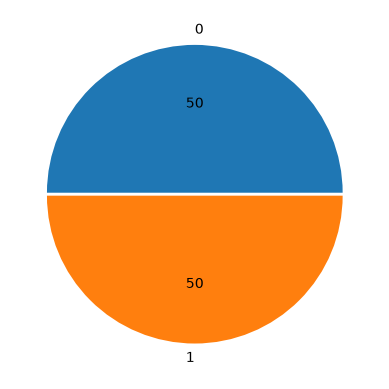

In [21]:
y_train.value_counts().plot(kind='pie',autopct='%0.0f',explode=[0.01,0.01])

<Axes: >

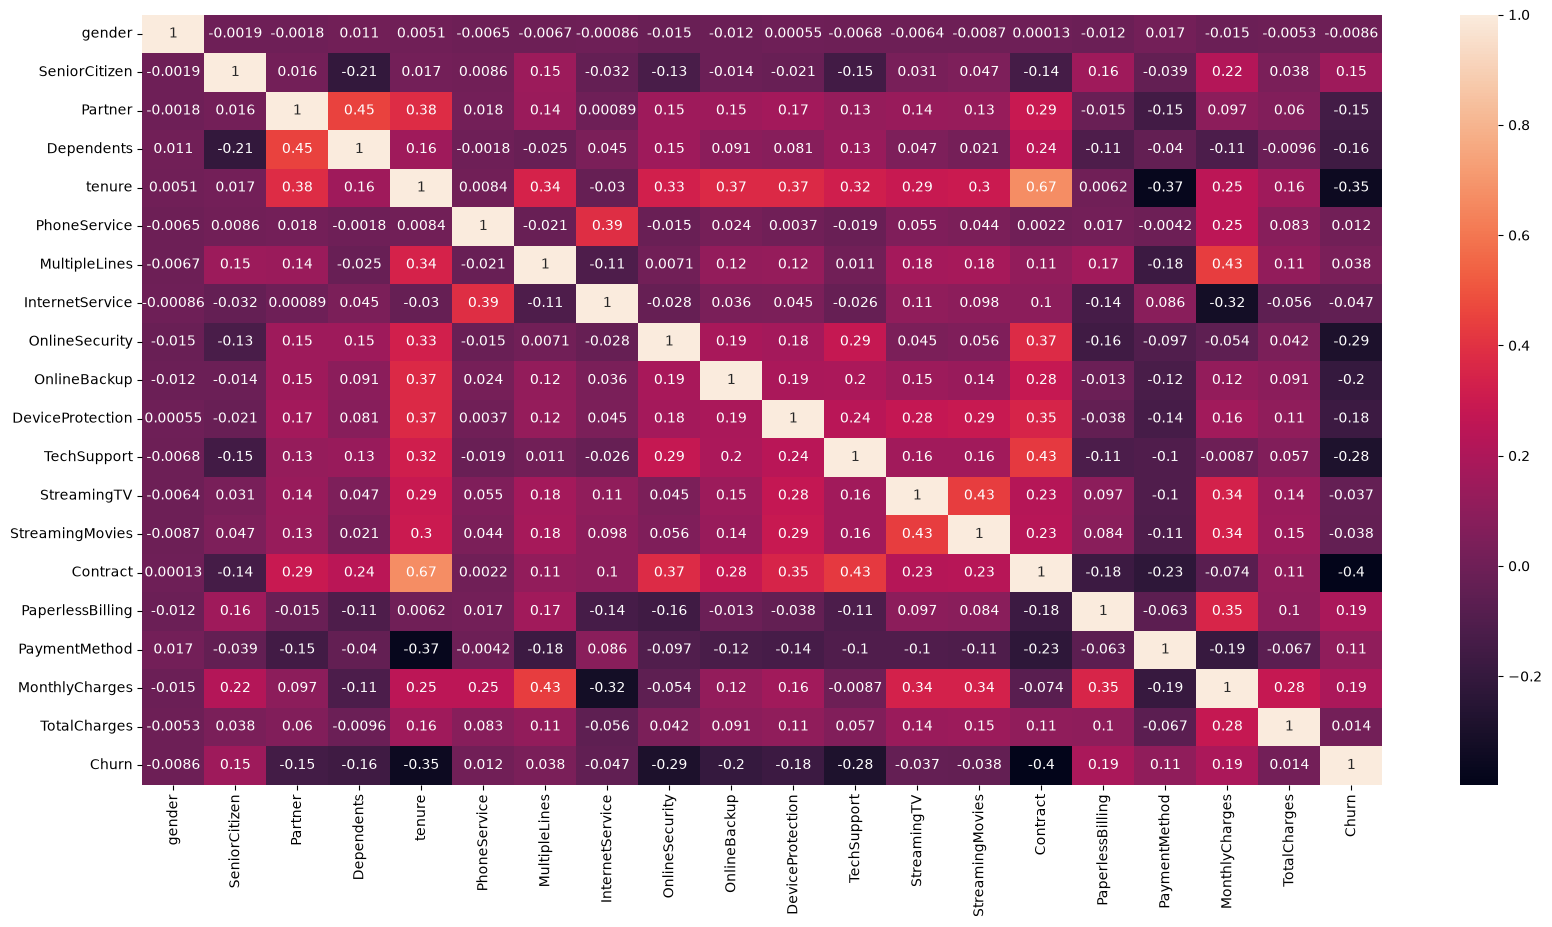

In [13]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(),annot=True)

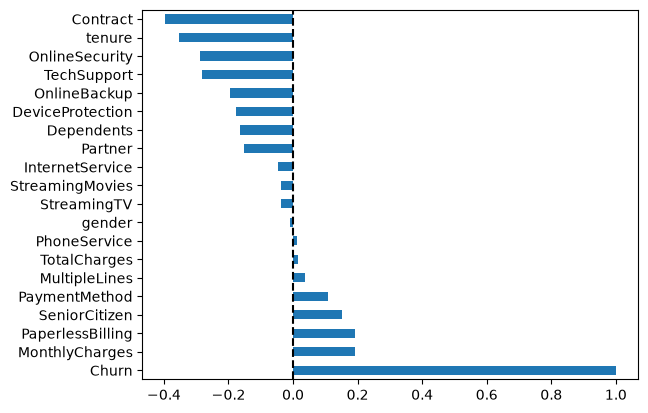

In [21]:
df.corr()['Churn'].sort_values(ascending=False).plot(kind='barh')
plt.axvline(x=0,linestyle='--',color='k')
plt.show()